# Remaining useful life of turbofan engines (C-MAPSS)

Course project in Deep Machine Learning at Chalmers, done together with Hooman Hamze.

We predict the remaining useful life (RUL) of an engine from a window of the last
50 cycles. The 21 sensor channels go through a 1D CNN, the 3 operating settings
through an LSTM, and the two embeddings are concatenated and mapped to one RUL value.
The loss is a smooth L1 loss plus a small part of the asymmetric NASA scoring
function, which punishes predicting too late harder than too early.

All four sub-datasets (FD001 to FD004) are used together. Put the `train_FD00x.txt`,
`test_FD00x.txt` and `RUL_FD00x.txt` files in `DATA_DIR` (see the README).

## Imports

In [ ]:
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import torch
from torch.utils.data import Dataset, DataLoader, random_split
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import matplotlib.pyplot as plt
import os

DATA_DIR = "data"

## Loading the data

In [ ]:
def load_cmaps_dataset(train_file, test_file, rul_file, dataset_name):
    train_df = pd.read_csv(train_file, sep=" ", header=None)
    test_df  = pd.read_csv(test_file,  sep=" ", header=None)
    rul_df   = pd.read_csv(rul_file,   sep=" ", header=None)

    train_df.dropna(axis=1, inplace=True)
    test_df.dropna(axis=1, inplace=True)

    cols = ['unit', 'time'] + [f'op_setting_{i}' for i in range(1, 4)] + [f'sensor_{i}' for i in range(1, 22)]
    train_df.columns = cols
    test_df.columns  = cols

    # RUL in the training set: cycles left until the engine fails
    rul_train = train_df.groupby('unit')['time'].max().reset_index()
    rul_train.columns = ['unit', 'max_time']
    train_df = train_df.merge(rul_train, on='unit')
    train_df['RUL'] = train_df['max_time'] - train_df['time']
    train_df.drop('max_time', axis=1, inplace=True)

    rul_test = test_df.groupby('unit')['time'].max().reset_index()
    rul_test.columns = ['unit', 'max_time']
    test_df = test_df.merge(rul_test, on='unit')
    test_df['RUL'] = test_df['max_time'] - test_df['time']
    test_df.drop('max_time', axis=1, inplace=True)

    true_rul = rul_df.values.flatten()
    for i, unit in enumerate(test_df['unit'].unique()):
        offset = float(true_rul[i])
        test_df.loc[test_df['unit'] == unit, 'RUL'] += offset  # test series stop before failure, RUL_FD00x gives the cycles left at the last row
    train_df['dataset'] = dataset_name
    test_df['dataset']  = dataset_name
    return train_df, test_df


fd_paths = {"FD001": ("train_FD001.txt", "test_FD001.txt", "RUL_FD001.txt"),
    "FD002": ("train_FD002.txt", "test_FD002.txt", "RUL_FD002.txt"),
    "FD003": ("train_FD003.txt", "test_FD003.txt", "RUL_FD003.txt"),
    "FD004": ("train_FD004.txt", "test_FD004.txt", "RUL_FD004.txt")}

all_train, all_test = [], []
for fd, (train_f, test_f, rul_f) in fd_paths.items():
  train_df, test_df = load_cmaps_dataset(os.path.join(DATA_DIR, train_f),
                                         os.path.join(DATA_DIR, test_f),
                                         os.path.join(DATA_DIR, rul_f), fd)
  all_train.append(train_df)
  all_test.append(test_df)
train_all = pd.concat(all_train, ignore_index=True)
test_all  = pd.concat(all_test, ignore_index=True)

Quick look at the sizes and the RUL distribution of the test sets.

In [ ]:
print("Train shape:", train_all.shape)
print("Test shape:", test_all.shape)
print(train_all['dataset'].value_counts())
print(test_all['dataset'].value_counts())
print(train_all.groupby('dataset')['unit'].nunique())
print(test_all.groupby('dataset')['unit'].nunique())
test_all.groupby("dataset")["RUL"].describe()

Train shape: (160359, 28)
Test shape: (104897, 28)
dataset
FD004    61249
FD002    53759
FD003    24720
FD001    20631
Name: count, dtype: int64
dataset
FD004    41214
FD002    33991
FD003    16596
FD001    13096
Name: count, dtype: int64
dataset
FD001    100
FD002    260
FD003    100
FD004    249
Name: unit, dtype: int64
dataset
FD001    100
FD002    259
FD003    100
FD004    248
Name: unit, dtype: int64


           count        mean         std  min    25%    50%    75%    max
dataset                                                                  
FD001     6253.0  156.590117   74.316890  7.0  107.0  150.0  202.0  447.0
FD002    16890.0  158.554292   81.054247  6.0   99.0  152.0  209.0  444.0
FD003     8207.0  180.822225   89.176720  7.0  118.0  170.0  232.0  519.0
FD004    21388.0  194.617870  101.693074  6.0  119.0  182.0  256.0  556.0

## Sliding windows and normalisation

Each sample is a window of 50 cycles of one engine and the target is the RUL at the
last cycle of the window. Units are split into train and validation (not windows), and
the min-max scaler is fitted on the training units only.

In [ ]:
class CMAPSSDataset(Dataset):
    def __init__(self, df, units, window_size=50):
        self.df = df
        self.units = units
        self.window_size = window_size
        self.sensor_cols = [c for c in df.columns if 'sensor_' in c]
        self.op_cols = [c for c in df.columns if 'op_setting' in c]

        # (unit, start row) for every window
        self.index_map = []
        for unit in units:
            unit_df = df[df['unit']==unit].reset_index(drop=True)
            for i in range(len(unit_df)-window_size+1):
                self.index_map.append((unit, i))

    def __len__(self):
        return len(self.index_map)

    def __getitem__(self, idx):
        unit, start = self.index_map[idx]
        unit_df = self.df[self.df['unit']==unit].reset_index(drop=True)
        window = unit_df.loc[start:start+self.window_size-1]
        Xs = window[self.sensor_cols].values.astype('float32')
        Xo = window[self.op_cols].values.astype('float32')
        y = window['RUL'].iloc[-1].astype('float32')
        return torch.tensor(Xs), torch.tensor(Xo), torch.tensor(y)


def prepare_datasets(train_all, test_all, val_frac=0.01, window_size=50, seed=42):
    # split by engine, not by window, to avoid leakage
    unit_ids = train_all['unit'].unique()
    rng = np.random.default_rng(seed)
    rng.shuffle(unit_ids)
    n_val = int(len(unit_ids) * val_frac)
    val_units = unit_ids[:n_val]
    train_units = unit_ids[n_val:]

    # scale with statistics from the training engines only
    feature_cols = [c for c in train_all.columns if 'op_setting' in c or 'sensor_' in c]
    scaler = MinMaxScaler()
    train_all.loc[train_all['unit'].isin(train_units), feature_cols] = scaler.fit_transform(train_all.loc[train_all['unit'].isin(train_units), feature_cols])
    train_all.loc[train_all['unit'].isin(val_units), feature_cols] = scaler.transform(train_all.loc[train_all['unit'].isin(val_units), feature_cols])
    test_all[feature_cols] = scaler.transform(test_all[feature_cols])

    train_dataset = CMAPSSDataset(train_all, train_units, window_size)
    val_dataset   = CMAPSSDataset(train_all, val_units, window_size)
    test_dataset  = CMAPSSDataset(test_all, test_all['unit'].unique(), window_size)

    return train_dataset, val_dataset, test_dataset, scaler

train_dataset, val_dataset, test_dataset, scaler = prepare_datasets(train_all, test_all, val_frac=0.01, window_size=50)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

Xs, Xo, y = next(iter(train_loader))
print("Sensors:", Xs.shape, "Ops:", Xo.shape, "Targets:", y.shape)

/tmp/ipython-input-606022153.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[0.91836735 0.91836735 0.89795918 ... 0.94897959 0.35714286 0.31632653]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_all.loc[train_all['unit'].isin(train_units), feature_cols] = scaler.fit_transform(train_all.loc[train_all['unit'].isin(train_units), feature_cols])
/tmp/ipython-input-606022153.py:42: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value '[1.         1.         1.         ... 1.         0.65116279 0.62790698]' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  train_all.loc[train_all['unit'].isin(train_units), feature_cols] = scaler.fit_transform(train_all.loc[train_all['unit'].isin(train_units), feature_cols])


Sensors: torch.Size([64, 50, 21]) Ops: torch.Size([64, 50, 3]) Targets: torch.Size([64])


## Model

Sensor branch: 1D CNN over time.

In [ ]:
class SensorCNN(nn.Module):
    def __init__(self, p_drop=0.2):
        super(SensorCNN, self).__init__()
        self.conv1 = nn.Conv1d(21, 64, kernel_size=3, stride=1, padding=1)  # [B, 64, 50]
        self.bn1 = nn.BatchNorm1d(64)
        self.do1 = nn.Dropout1d(p_drop)
        self.conv2 = nn.Conv1d(64, 128, kernel_size=3, stride=2, padding=1) # [B, 128, 25]
        self.bn2 = nn.BatchNorm1d(128)
        self.do2 = nn.Dropout1d(p_drop)
        self.conv3 = nn.Conv1d(128, 64, kernel_size=3, stride=2, padding=1) # [B, 64, 13]
        self.bn3 = nn.BatchNorm1d(64)
        self.do3 = nn.Dropout1d(p_drop)
        self.conv4 = nn.Conv1d(64, 32, kernel_size=3, stride=2, padding=1)  # [B, 32, 7]
        self.bn4 = nn.BatchNorm1d(32)
        self.do4 = nn.Dropout1d(p_drop)
        self.conv5 = nn.Conv1d(32, 16, kernel_size=3, stride=2, padding=1)  # [B, 16, 4]
        self.bn5 = nn.BatchNorm1d(16)
        self.do5 = nn.Dropout1d(p_drop)
        self.conv6 = nn.Conv1d(16, 64, kernel_size=3, stride=2, padding=1) # [B, 64, 2]

    def forward(self, x):
        x = x.permute(0, 2, 1)  # [B, 21, 50]
        x = F.relu(self.bn1(self.conv1(x))); x = self.do1(x)
        x = F.relu(self.bn2(self.conv2(x))); x = self.do2(x)
        x = F.relu(self.bn3(self.conv3(x))); x = self.do3(x)
        x = F.relu(self.bn4(self.conv4(x))); x = self.do4(x)
        x = F.relu(self.bn5(self.conv5(x))); x = self.do5(x)
        x = self.conv6(x)   # [B, 64, 2]
        x = F.adaptive_avg_pool1d(x, 1) # [B, 64, 1]
        x = x.squeeze(-1)   # [B, 64]
        return x


In [ ]:
model = SensorCNN()
batch = next(iter(train_loader))
Xs, Xo, y = batch
out = model(Xs)
print("CNN output shape:", out.shape)
print(out[:5])
print("Any NaNs in output?", torch.isnan(out).any().item())


CNN output shape: torch.Size([64, 64])
tensor([[ 0.1462, -0.5334, -0.1221, -0.3918, -0.6211, -0.2453,  0.0955,  0.6182,
          0.2758,  0.0470,  0.2632, -0.1892,  0.0648, -0.6844,  0.3659,  0.0697,
         -0.4450, -0.4242,  0.2237,  0.1021, -0.1445,  0.2261,  0.3736,  0.7332,
         -0.4017, -0.2443,  0.3055,  0.1921,  0.8091, -0.0961, -0.3426,  0.6445,
         -0.7824,  0.6424,  1.1363,  0.1747, -0.0170, -0.8816,  0.3966,  0.2967,
         -0.3583,  0.4238,  0.9223, -0.2349,  0.4391,  0.1367, -0.5494,  0.4877,
         -0.2518, -0.3381,  0.1096,  0.2545, -0.2274, -0.6035,  0.3273,  0.1152,
         -0.3382,  0.1521, -0.3816,  0.6128,  0.5520, -0.0841, -0.0299, -0.4047],
        [-0.8074, -0.1463,  0.4248,  0.2323,  0.1283, -0.3247,  0.1181,  0.3613,
          0.7791,  1.0749,  0.6559,  0.3659, -0.1585,  0.0497, -0.2441,  0.2990,
          0.8544, -0.1586, -1.0292,  0.8850,  0.1081,  0.2886, -0.8907, -0.1455,
          0.7052,  0.4334, -0.2778, -0.0837,  1.1986, -0.2961, -0.681

Operating-settings branch: a small LSTM, we keep the last hidden state.

In [ ]:
class OpLSTM(nn.Module):
    def __init__(self, input_size=3, hidden_size=64, num_layers=1):
        super(OpLSTM, self).__init__()
        self.lstm = nn.LSTM(input_size=input_size,
                            hidden_size=hidden_size,
                            num_layers=num_layers,
                            batch_first=True)  # [batch, seq_len, features]
        self.ln = nn.LayerNorm(hidden_size)

    def forward(self, x):
        # x: [batch_size, window_size, input_size]
        _, (hn, _) = self.lstm(x)         # hn: [num_layers, batch_size, hidden_size]
        x = hn[-1]
        x = self.ln(x)
        return x                          # [batch_size, hidden_size]


In [ ]:
op_model = OpLSTM(input_size=Xo.shape[2], hidden_size=64, num_layers=1)
Xs, Xo, y = next(iter(train_loader))
out = op_model(Xo)
print("LSTM output shape:", out.shape)
print(out[:5])
print("Any NaNs in output?", torch.isnan(out).any().item())

LSTM output shape: torch.Size([64, 64])
tensor([[ 0.1303,  0.2099,  1.7622, -0.4980, -1.0101,  0.1921, -1.1621,  1.0715,
         -0.6554,  1.6216, -0.2627, -0.3633, -0.7498,  0.8196, -0.0041,  0.9534,
         -1.1511,  0.6100,  1.8107, -0.2860, -0.0485, -0.5300, -1.1436, -0.9111,
          0.6081,  1.2808, -0.1312,  0.2050, -0.3879,  1.8550,  0.5789, -0.2669,
         -0.9767,  0.9510, -1.2689,  0.2829, -0.3341, -1.9827, -1.5010,  0.1742,
         -1.0958,  0.7326,  1.6120, -0.9131,  0.6382,  1.3191, -0.3623, -0.9006,
         -1.6928,  1.1197,  0.1484,  0.5195, -1.0714,  0.8517, -0.6874, -1.6284,
          0.3227, -1.4602,  0.5855,  2.3972,  0.2442,  0.9660, -1.0120, -0.1250],
        [ 0.2300,  0.9589,  2.1195, -1.3924, -0.3154, -0.7629, -1.1626, -0.0344,
         -0.5703,  1.0465,  0.3853,  0.1082, -1.5359,  1.2764,  0.7476,  0.2216,
         -1.2186,  0.1059,  0.4613,  0.3397,  0.0344, -1.0779, -0.9367, -1.5198,
          0.3525,  1.1740,  0.4579, -0.0453, -0.5663,  0.6471,  1.24

Fusion: concatenate both embeddings (the CNN part gets a learnable weight) and regress the RUL.

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

class RULFusionModel(nn.Module):
    def __init__(self):
        super(RULFusionModel, self).__init__()
        self.cnn = SensorCNN()
        self.lstm = OpLSTM()

        # Learnable scalar weight for CNN output
        self.cnn_weight = nn.Parameter(torch.tensor(1.0))

        # Fusion layers
        self.fusion_fc1 = nn.Linear(128, 32)
        self.fusion_fc2 = nn.Linear(32, 1)

    def forward(self, Xs, Xo):
        cnn_out = self.cnn(Xs)               # [B, 64]
        lstm_out = self.lstm(Xo)             # [B, 64]

        weighted_cnn = self.cnn_weight * cnn_out

        fusion = torch.cat([weighted_cnn, lstm_out], dim=1)  # [B, 128]
        x = F.relu(self.fusion_fc1(fusion))                  # [B, 32]
        x = self.fusion_fc2(x)                               # [B, 1]
        return x

In [ ]:
model = RULFusionModel().to(device)
Xs, Xo, y = next(iter(train_loader))
Xs, Xo, y = Xs.to(device), Xo.to(device), y.to(device)
out = model(Xs, Xo)
print("Fusion model output shape:", out.shape)
print(out[:5])
print("Any NaNs in output?", torch.isnan(out).any().item())


Fusion model output shape: torch.Size([64, 1])
tensor([[-0.3043],
        [-0.2948],
        [-0.2968],
        [-0.3332],
        [-0.2805]], grad_fn=<SliceBackward0>)
Any NaNs in output? False


## Loss and NASA score

The NASA score is `exp(d/10) - 1` for late predictions (d > 0) and `exp(-d/13) - 1`
for early ones. Its exponential makes it unstable as the only loss, so the error is
clamped and it is added to a smooth L1 loss with weight `alpha`.

In [ ]:
def nasa_loss(pred, target, clamp_pos=40.0, clamp_neg=40.0):
    d = pred - target
    d_pos = torch.clamp(d, max=clamp_pos)     # tame huge early grads
    d_neg = torch.clamp(-d, max=clamp_neg)
    over  = torch.exp(d_pos / 10.0) - 1.0
    under = torch.exp(d_neg / 13.0) - 1.0
    return torch.where(d >= 0, over, under).mean()


def fused_loss(pred, target, alpha=0.1):
    pred = pred.squeeze(-1)  # (B,)
    base = F.smooth_l1_loss(pred, target, beta=2.0)
    nasa = nasa_loss(pred, target)
    return base + alpha * nasa


def nasa_score(pred, target):
    d = (pred - target).cpu().numpy().flatten()
    score = 0.0
    for di in d:
        if di >= 0:
            score += np.exp(di / 10.0) - 1.0
        else:
            score += np.exp(-di / 13.0) - 1.0
    return score

## Training

After every epoch we print the validation loss, the NASA score and how often the
prediction is too late (`Over %`), and plot predicted vs. true RUL on the validation windows.

Epoch 1 | Batch 50/2296 | Batch Loss: 106.4984
Epoch 1 | Batch 100/2296 | Batch Loss: 74.3658
Epoch 1 | Batch 150/2296 | Batch Loss: 72.6202
Epoch 1 | Batch 200/2296 | Batch Loss: 56.4375
Epoch 1 | Batch 250/2296 | Batch Loss: 42.5798
Epoch 1 | Batch 300/2296 | Batch Loss: 54.5074
Epoch 1 | Batch 350/2296 | Batch Loss: 51.1477
Epoch 1 | Batch 400/2296 | Batch Loss: 46.8654
Epoch 1 | Batch 450/2296 | Batch Loss: 52.8769
Epoch 1 | Batch 500/2296 | Batch Loss: 43.5877
Epoch 1 | Batch 550/2296 | Batch Loss: 51.9551
Epoch 1 | Batch 600/2296 | Batch Loss: 42.3909
Epoch 1 | Batch 650/2296 | Batch Loss: 42.1252
Epoch 1 | Batch 700/2296 | Batch Loss: 42.7014
Epoch 1 | Batch 750/2296 | Batch Loss: 45.3519
Epoch 1 | Batch 800/2296 | Batch Loss: 52.2097
Epoch 1 | Batch 850/2296 | Batch Loss: 46.6618
Epoch 1 | Batch 900/2296 | Batch Loss: 45.6965
Epoch 1 | Batch 950/2296 | Batch Loss: 28.3921
Epoch 1 | Batch 1000/2296 | Batch Loss: 40.6372
Epoch 1 | Batch 1050/2296 | Batch Loss: 44.4695
Epoch 1 | B

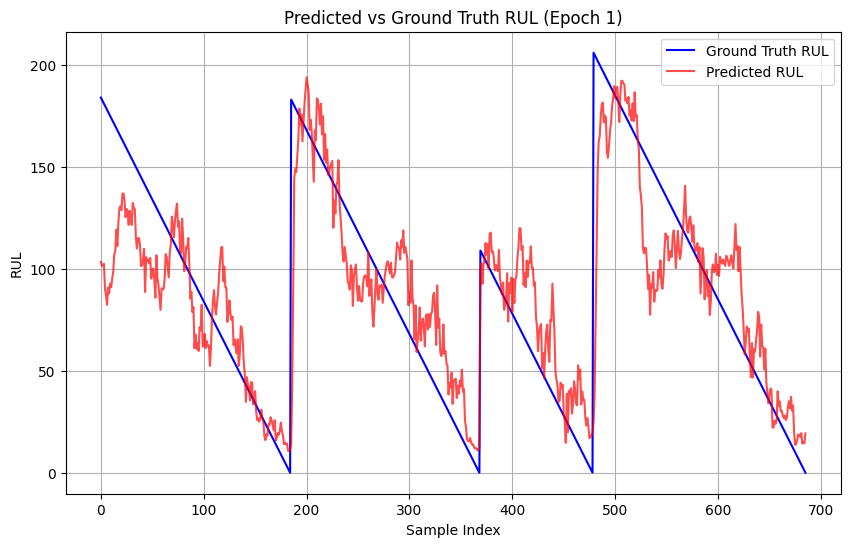

Epoch 2 | Batch 50/2296 | Batch Loss: 37.5480
Epoch 2 | Batch 100/2296 | Batch Loss: 53.7997
Epoch 2 | Batch 150/2296 | Batch Loss: 31.1199
Epoch 2 | Batch 200/2296 | Batch Loss: 33.9305
Epoch 2 | Batch 250/2296 | Batch Loss: 49.0010
Epoch 2 | Batch 300/2296 | Batch Loss: 40.2630
Epoch 2 | Batch 350/2296 | Batch Loss: 31.0865
Epoch 2 | Batch 400/2296 | Batch Loss: 40.4173
Epoch 2 | Batch 450/2296 | Batch Loss: 42.4542
Epoch 2 | Batch 500/2296 | Batch Loss: 36.1967
Epoch 2 | Batch 550/2296 | Batch Loss: 40.3509
Epoch 2 | Batch 600/2296 | Batch Loss: 43.3936
Epoch 2 | Batch 650/2296 | Batch Loss: 43.7334
Epoch 2 | Batch 700/2296 | Batch Loss: 30.8425
Epoch 2 | Batch 750/2296 | Batch Loss: 31.9102
Epoch 2 | Batch 800/2296 | Batch Loss: 47.8461
Epoch 2 | Batch 850/2296 | Batch Loss: 54.8923
Epoch 2 | Batch 900/2296 | Batch Loss: 43.4218
Epoch 2 | Batch 950/2296 | Batch Loss: 61.2298
Epoch 2 | Batch 1000/2296 | Batch Loss: 48.7248
Epoch 2 | Batch 1050/2296 | Batch Loss: 29.3238
Epoch 2 | Ba

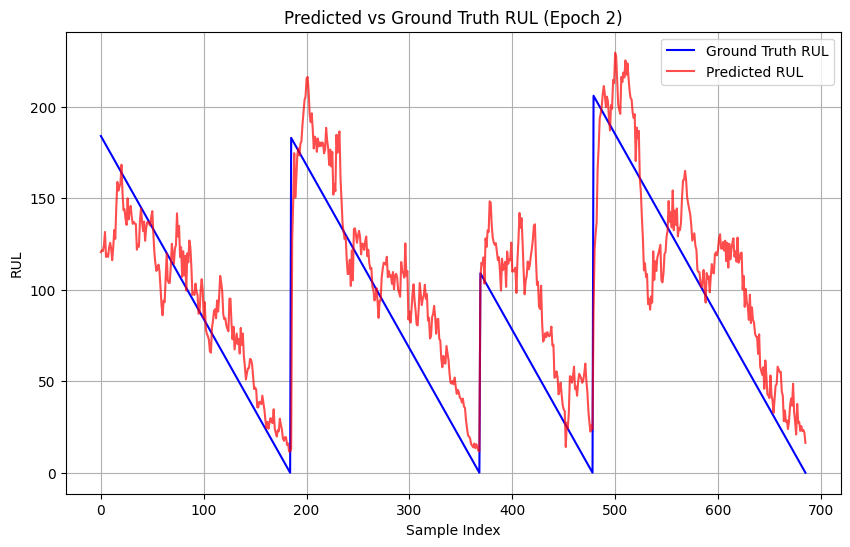

Epoch 3 | Batch 50/2296 | Batch Loss: 26.5675
Epoch 3 | Batch 100/2296 | Batch Loss: 33.0337
Epoch 3 | Batch 150/2296 | Batch Loss: 35.9291
Epoch 3 | Batch 200/2296 | Batch Loss: 31.8479
Epoch 3 | Batch 250/2296 | Batch Loss: 43.0538
Epoch 3 | Batch 300/2296 | Batch Loss: 40.2136
Epoch 3 | Batch 350/2296 | Batch Loss: 39.1863
Epoch 3 | Batch 400/2296 | Batch Loss: 29.4218
Epoch 3 | Batch 450/2296 | Batch Loss: 41.2992
Epoch 3 | Batch 500/2296 | Batch Loss: 38.0646
Epoch 3 | Batch 550/2296 | Batch Loss: 40.2397
Epoch 3 | Batch 600/2296 | Batch Loss: 23.9905
Epoch 3 | Batch 650/2296 | Batch Loss: 27.4232
Epoch 3 | Batch 700/2296 | Batch Loss: 42.3813
Epoch 3 | Batch 750/2296 | Batch Loss: 35.0365
Epoch 3 | Batch 800/2296 | Batch Loss: 35.0635
Epoch 3 | Batch 850/2296 | Batch Loss: 29.9109
Epoch 3 | Batch 900/2296 | Batch Loss: 35.6852
Epoch 3 | Batch 950/2296 | Batch Loss: 46.1874
Epoch 3 | Batch 1000/2296 | Batch Loss: 37.6961
Epoch 3 | Batch 1050/2296 | Batch Loss: 31.9876
Epoch 3 | Ba

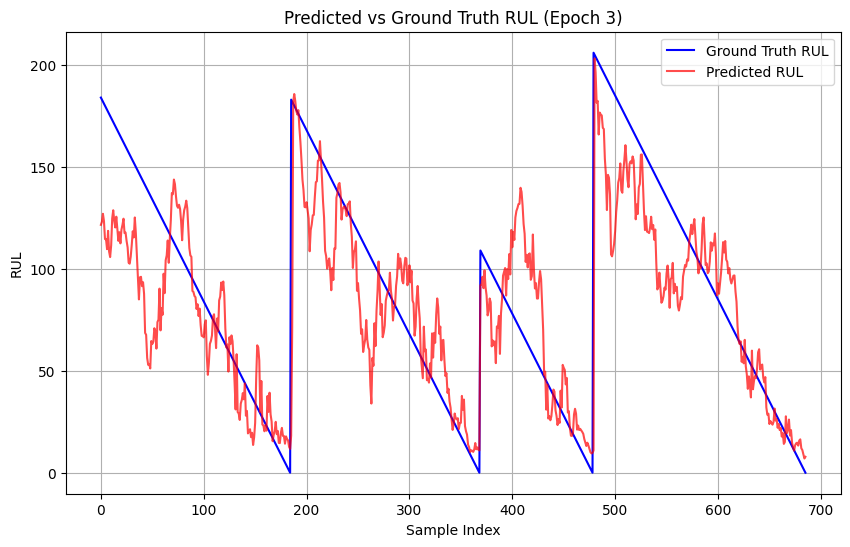

Epoch 4 | Batch 50/2296 | Batch Loss: 36.8045
Epoch 4 | Batch 100/2296 | Batch Loss: 31.3924
Epoch 4 | Batch 150/2296 | Batch Loss: 40.9908
Epoch 4 | Batch 200/2296 | Batch Loss: 36.7505
Epoch 4 | Batch 250/2296 | Batch Loss: 34.0721
Epoch 4 | Batch 300/2296 | Batch Loss: 37.9370
Epoch 4 | Batch 350/2296 | Batch Loss: 37.0514
Epoch 4 | Batch 400/2296 | Batch Loss: 35.8109
Epoch 4 | Batch 450/2296 | Batch Loss: 32.0401
Epoch 4 | Batch 500/2296 | Batch Loss: 36.3722
Epoch 4 | Batch 550/2296 | Batch Loss: 30.0287
Epoch 4 | Batch 600/2296 | Batch Loss: 34.3497
Epoch 4 | Batch 650/2296 | Batch Loss: 38.8628
Epoch 4 | Batch 700/2296 | Batch Loss: 33.3431
Epoch 4 | Batch 750/2296 | Batch Loss: 43.0771
Epoch 4 | Batch 800/2296 | Batch Loss: 48.3759
Epoch 4 | Batch 850/2296 | Batch Loss: 30.8555
Epoch 4 | Batch 900/2296 | Batch Loss: 39.6689
Epoch 4 | Batch 950/2296 | Batch Loss: 28.0161
Epoch 4 | Batch 1000/2296 | Batch Loss: 39.6022
Epoch 4 | Batch 1050/2296 | Batch Loss: 32.4587
Epoch 4 | Ba

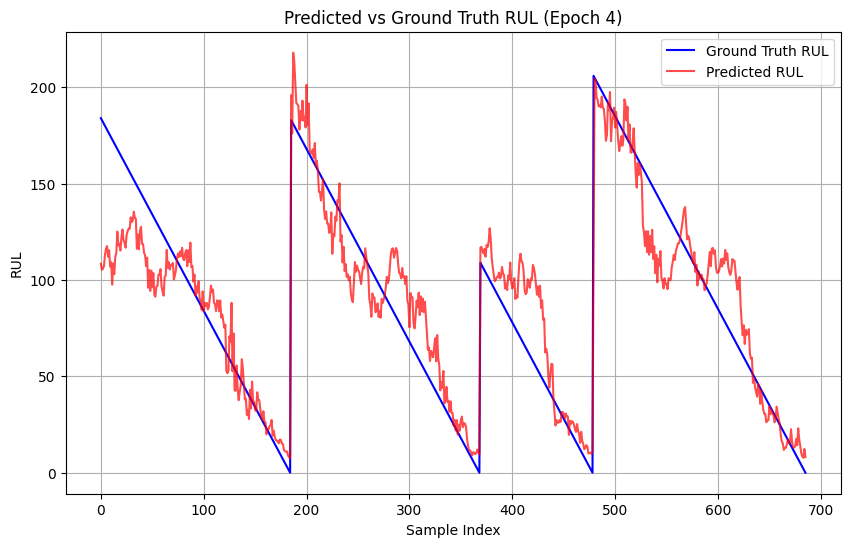

Epoch 5 | Batch 50/2296 | Batch Loss: 28.3166
Epoch 5 | Batch 100/2296 | Batch Loss: 36.1962
Epoch 5 | Batch 150/2296 | Batch Loss: 33.1111
Epoch 5 | Batch 200/2296 | Batch Loss: 42.3748
Epoch 5 | Batch 250/2296 | Batch Loss: 43.3077
Epoch 5 | Batch 300/2296 | Batch Loss: 32.5755
Epoch 5 | Batch 350/2296 | Batch Loss: 31.1637
Epoch 5 | Batch 400/2296 | Batch Loss: 34.5821
Epoch 5 | Batch 450/2296 | Batch Loss: 28.2973
Epoch 5 | Batch 500/2296 | Batch Loss: 30.8631
Epoch 5 | Batch 550/2296 | Batch Loss: 27.4498
Epoch 5 | Batch 600/2296 | Batch Loss: 31.7133
Epoch 5 | Batch 650/2296 | Batch Loss: 31.0423
Epoch 5 | Batch 700/2296 | Batch Loss: 44.9605
Epoch 5 | Batch 750/2296 | Batch Loss: 31.5952
Epoch 5 | Batch 800/2296 | Batch Loss: 24.6188
Epoch 5 | Batch 850/2296 | Batch Loss: 26.7213
Epoch 5 | Batch 900/2296 | Batch Loss: 30.7672
Epoch 5 | Batch 950/2296 | Batch Loss: 30.9063
Epoch 5 | Batch 1000/2296 | Batch Loss: 35.3439
Epoch 5 | Batch 1050/2296 | Batch Loss: 32.2038
Epoch 5 | Ba

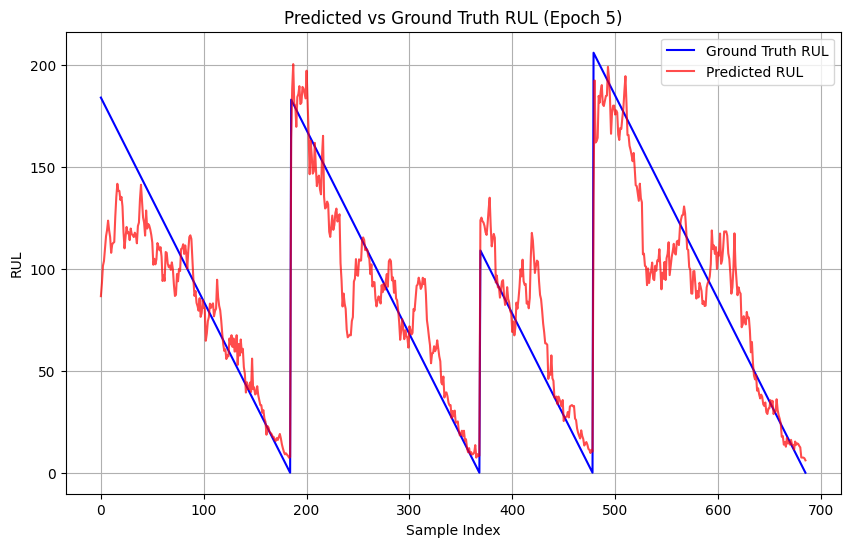

Epoch 6 | Batch 50/2296 | Batch Loss: 32.8008
Epoch 6 | Batch 100/2296 | Batch Loss: 27.9149
Epoch 6 | Batch 150/2296 | Batch Loss: 33.0419
Epoch 6 | Batch 200/2296 | Batch Loss: 30.8410
Epoch 6 | Batch 250/2296 | Batch Loss: 33.9151
Epoch 6 | Batch 300/2296 | Batch Loss: 30.2831
Epoch 6 | Batch 350/2296 | Batch Loss: 31.8352
Epoch 6 | Batch 400/2296 | Batch Loss: 36.0938
Epoch 6 | Batch 450/2296 | Batch Loss: 35.3007
Epoch 6 | Batch 500/2296 | Batch Loss: 35.5159
Epoch 6 | Batch 550/2296 | Batch Loss: 33.5007
Epoch 6 | Batch 600/2296 | Batch Loss: 38.7215
Epoch 6 | Batch 650/2296 | Batch Loss: 47.0461
Epoch 6 | Batch 700/2296 | Batch Loss: 28.6511
Epoch 6 | Batch 750/2296 | Batch Loss: 25.8479
Epoch 6 | Batch 800/2296 | Batch Loss: 25.8904
Epoch 6 | Batch 850/2296 | Batch Loss: 36.1622
Epoch 6 | Batch 900/2296 | Batch Loss: 31.5195
Epoch 6 | Batch 950/2296 | Batch Loss: 43.1731
Epoch 6 | Batch 1000/2296 | Batch Loss: 38.3552
Epoch 6 | Batch 1050/2296 | Batch Loss: 29.6077
Epoch 6 | Ba

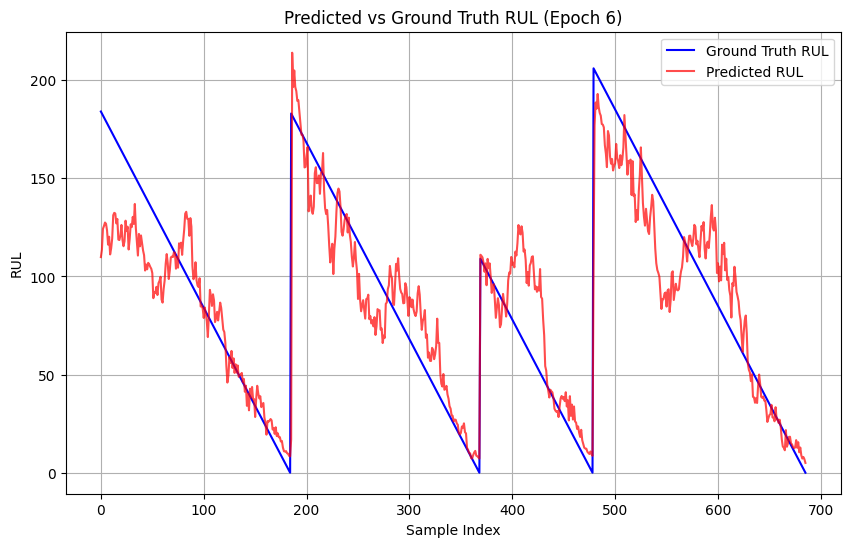

Epoch 7 | Batch 50/2296 | Batch Loss: 30.7708
Epoch 7 | Batch 100/2296 | Batch Loss: 36.3685
Epoch 7 | Batch 150/2296 | Batch Loss: 30.4027
Epoch 7 | Batch 200/2296 | Batch Loss: 28.2319
Epoch 7 | Batch 250/2296 | Batch Loss: 40.9335
Epoch 7 | Batch 300/2296 | Batch Loss: 39.7787
Epoch 7 | Batch 350/2296 | Batch Loss: 28.5855
Epoch 7 | Batch 400/2296 | Batch Loss: 38.7014
Epoch 7 | Batch 450/2296 | Batch Loss: 34.0072
Epoch 7 | Batch 500/2296 | Batch Loss: 28.4095
Epoch 7 | Batch 550/2296 | Batch Loss: 25.7430
Epoch 7 | Batch 600/2296 | Batch Loss: 37.1255
Epoch 7 | Batch 650/2296 | Batch Loss: 34.8444
Epoch 7 | Batch 700/2296 | Batch Loss: 23.5138
Epoch 7 | Batch 750/2296 | Batch Loss: 40.3769
Epoch 7 | Batch 800/2296 | Batch Loss: 24.2976
Epoch 7 | Batch 850/2296 | Batch Loss: 36.6326
Epoch 7 | Batch 900/2296 | Batch Loss: 37.0715
Epoch 7 | Batch 950/2296 | Batch Loss: 30.6434
Epoch 7 | Batch 1000/2296 | Batch Loss: 35.2549
Epoch 7 | Batch 1050/2296 | Batch Loss: 32.0505
Epoch 7 | Ba

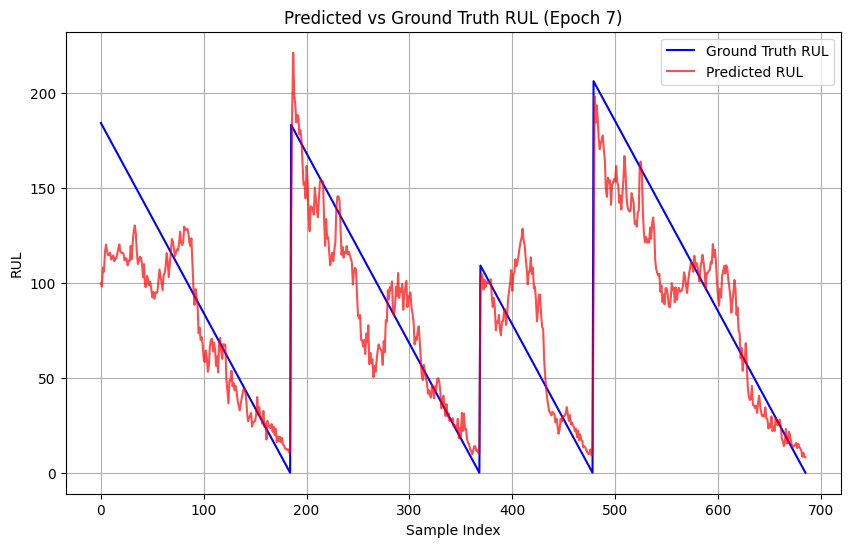

Epoch 8 | Batch 50/2296 | Batch Loss: 28.0341
Epoch 8 | Batch 100/2296 | Batch Loss: 30.6114
Epoch 8 | Batch 150/2296 | Batch Loss: 33.2486
Epoch 8 | Batch 200/2296 | Batch Loss: 35.7108
Epoch 8 | Batch 250/2296 | Batch Loss: 27.9112
Epoch 8 | Batch 300/2296 | Batch Loss: 36.7674
Epoch 8 | Batch 350/2296 | Batch Loss: 39.1062
Epoch 8 | Batch 400/2296 | Batch Loss: 28.0049
Epoch 8 | Batch 450/2296 | Batch Loss: 38.5146
Epoch 8 | Batch 500/2296 | Batch Loss: 32.0568
Epoch 8 | Batch 550/2296 | Batch Loss: 34.7462
Epoch 8 | Batch 600/2296 | Batch Loss: 36.9784
Epoch 8 | Batch 650/2296 | Batch Loss: 28.4799
Epoch 8 | Batch 700/2296 | Batch Loss: 35.9138
Epoch 8 | Batch 750/2296 | Batch Loss: 34.0132
Epoch 8 | Batch 800/2296 | Batch Loss: 36.8799
Epoch 8 | Batch 850/2296 | Batch Loss: 30.1347
Epoch 8 | Batch 900/2296 | Batch Loss: 30.9202
Epoch 8 | Batch 950/2296 | Batch Loss: 29.1271
Epoch 8 | Batch 1000/2296 | Batch Loss: 35.9657
Epoch 8 | Batch 1050/2296 | Batch Loss: 33.7659
Epoch 8 | Ba

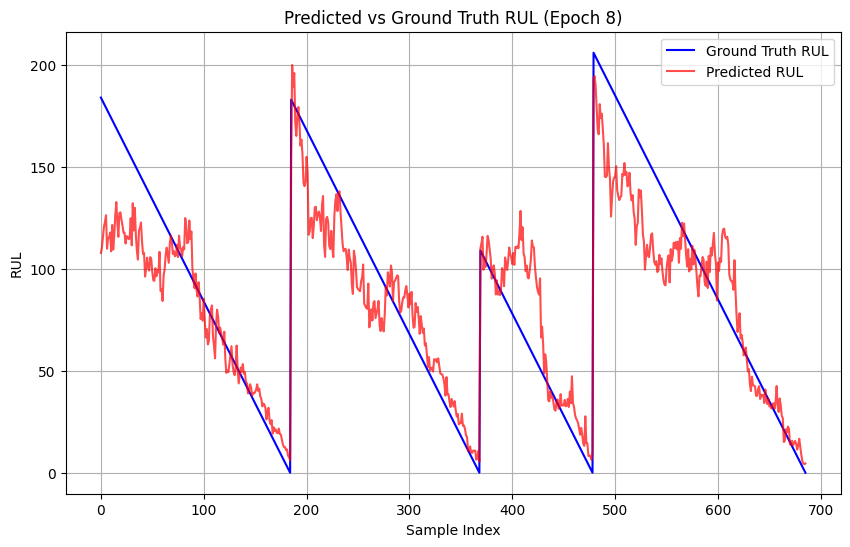

Epoch 9 | Batch 50/2296 | Batch Loss: 35.7307
Epoch 9 | Batch 100/2296 | Batch Loss: 29.3011
Epoch 9 | Batch 150/2296 | Batch Loss: 27.1445
Epoch 9 | Batch 200/2296 | Batch Loss: 30.2762
Epoch 9 | Batch 250/2296 | Batch Loss: 33.8785
Epoch 9 | Batch 300/2296 | Batch Loss: 33.2317
Epoch 9 | Batch 350/2296 | Batch Loss: 37.1991
Epoch 9 | Batch 400/2296 | Batch Loss: 27.1181
Epoch 9 | Batch 450/2296 | Batch Loss: 41.4246
Epoch 9 | Batch 500/2296 | Batch Loss: 26.4352
Epoch 9 | Batch 550/2296 | Batch Loss: 29.9219
Epoch 9 | Batch 600/2296 | Batch Loss: 29.3595
Epoch 9 | Batch 650/2296 | Batch Loss: 44.9393
Epoch 9 | Batch 700/2296 | Batch Loss: 38.6591
Epoch 9 | Batch 750/2296 | Batch Loss: 29.8951
Epoch 9 | Batch 800/2296 | Batch Loss: 32.1377
Epoch 9 | Batch 850/2296 | Batch Loss: 38.7490
Epoch 9 | Batch 900/2296 | Batch Loss: 33.1253
Epoch 9 | Batch 950/2296 | Batch Loss: 37.3627
Epoch 9 | Batch 1000/2296 | Batch Loss: 29.6691
Epoch 9 | Batch 1050/2296 | Batch Loss: 48.9247
Epoch 9 | Ba

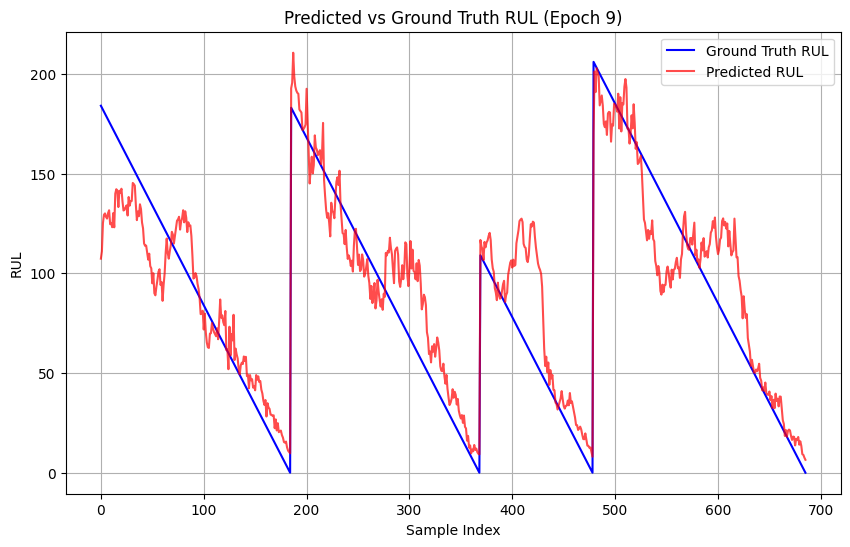

Epoch 10 | Batch 50/2296 | Batch Loss: 41.6153
Epoch 10 | Batch 100/2296 | Batch Loss: 31.0118
Epoch 10 | Batch 150/2296 | Batch Loss: 42.0062
Epoch 10 | Batch 200/2296 | Batch Loss: 32.9888
Epoch 10 | Batch 250/2296 | Batch Loss: 30.4374
Epoch 10 | Batch 300/2296 | Batch Loss: 35.7245
Epoch 10 | Batch 350/2296 | Batch Loss: 22.2759
Epoch 10 | Batch 400/2296 | Batch Loss: 25.3522
Epoch 10 | Batch 450/2296 | Batch Loss: 29.2665
Epoch 10 | Batch 500/2296 | Batch Loss: 41.0349
Epoch 10 | Batch 550/2296 | Batch Loss: 28.3011
Epoch 10 | Batch 600/2296 | Batch Loss: 31.3494
Epoch 10 | Batch 650/2296 | Batch Loss: 28.9076
Epoch 10 | Batch 700/2296 | Batch Loss: 29.5717
Epoch 10 | Batch 750/2296 | Batch Loss: 50.6627
Epoch 10 | Batch 800/2296 | Batch Loss: 34.6533
Epoch 10 | Batch 850/2296 | Batch Loss: 39.5504
Epoch 10 | Batch 900/2296 | Batch Loss: 34.9182
Epoch 10 | Batch 950/2296 | Batch Loss: 32.1205
Epoch 10 | Batch 1000/2296 | Batch Loss: 28.2215
Epoch 10 | Batch 1050/2296 | Batch Loss:

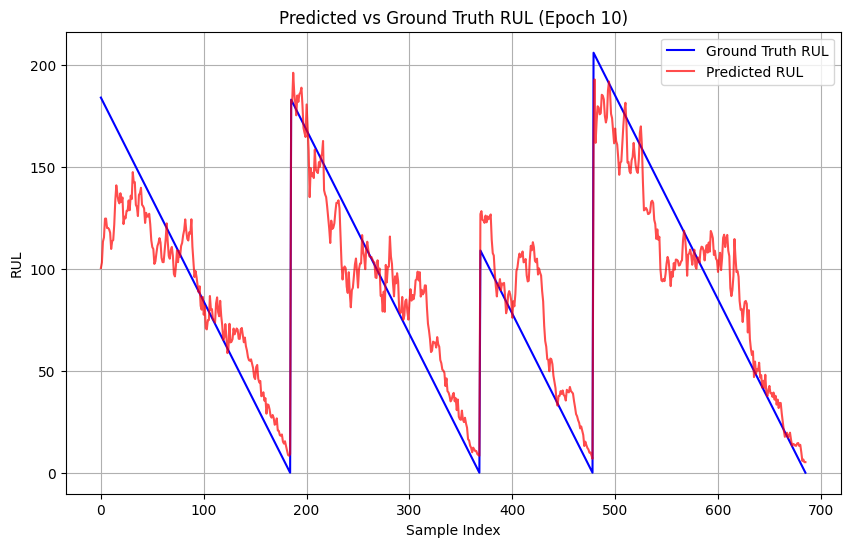

Epoch 11 | Batch 50/2296 | Batch Loss: 28.2047
Epoch 11 | Batch 100/2296 | Batch Loss: 30.0637
Epoch 11 | Batch 150/2296 | Batch Loss: 28.4316
Epoch 11 | Batch 200/2296 | Batch Loss: 31.4648
Epoch 11 | Batch 250/2296 | Batch Loss: 30.9217
Epoch 11 | Batch 300/2296 | Batch Loss: 29.8002
Epoch 11 | Batch 350/2296 | Batch Loss: 38.7954
Epoch 11 | Batch 400/2296 | Batch Loss: 34.9648
Epoch 11 | Batch 450/2296 | Batch Loss: 35.0148
Epoch 11 | Batch 500/2296 | Batch Loss: 27.8801
Epoch 11 | Batch 550/2296 | Batch Loss: 43.5773
Epoch 11 | Batch 600/2296 | Batch Loss: 26.8049
Epoch 11 | Batch 650/2296 | Batch Loss: 24.2321
Epoch 11 | Batch 700/2296 | Batch Loss: 37.8301
Epoch 11 | Batch 750/2296 | Batch Loss: 32.7033
Epoch 11 | Batch 800/2296 | Batch Loss: 24.8529
Epoch 11 | Batch 850/2296 | Batch Loss: 33.5754
Epoch 11 | Batch 900/2296 | Batch Loss: 30.9220
Epoch 11 | Batch 950/2296 | Batch Loss: 30.0050
Epoch 11 | Batch 1000/2296 | Batch Loss: 30.8502
Epoch 11 | Batch 1050/2296 | Batch Loss:

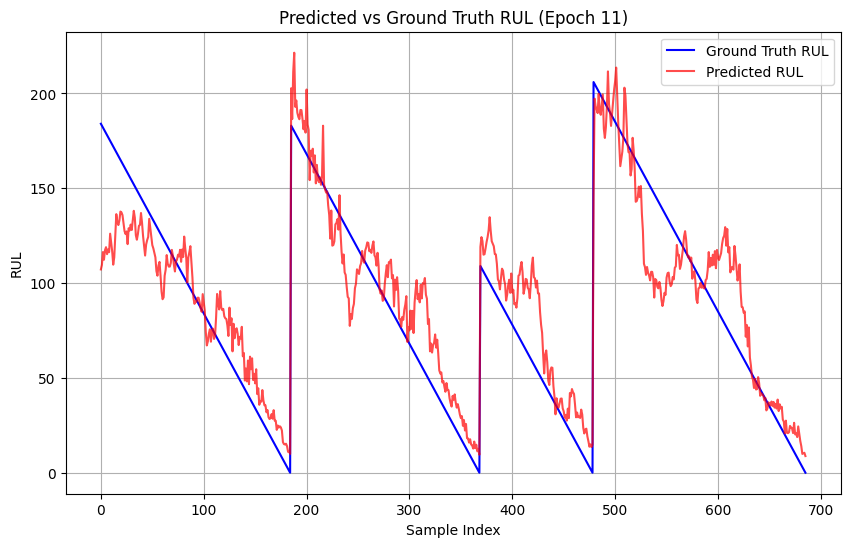

Epoch 12 | Batch 50/2296 | Batch Loss: 29.1880
Epoch 12 | Batch 100/2296 | Batch Loss: 28.5790
Epoch 12 | Batch 150/2296 | Batch Loss: 28.7495
Epoch 12 | Batch 200/2296 | Batch Loss: 46.0353
Epoch 12 | Batch 250/2296 | Batch Loss: 42.2303
Epoch 12 | Batch 300/2296 | Batch Loss: 25.6918
Epoch 12 | Batch 350/2296 | Batch Loss: 27.7457
Epoch 12 | Batch 400/2296 | Batch Loss: 39.8056
Epoch 12 | Batch 450/2296 | Batch Loss: 26.4368
Epoch 12 | Batch 500/2296 | Batch Loss: 30.9587
Epoch 12 | Batch 550/2296 | Batch Loss: 29.1061
Epoch 12 | Batch 600/2296 | Batch Loss: 26.0027
Epoch 12 | Batch 650/2296 | Batch Loss: 24.7729
Epoch 12 | Batch 700/2296 | Batch Loss: 27.1559
Epoch 12 | Batch 750/2296 | Batch Loss: 33.7803
Epoch 12 | Batch 800/2296 | Batch Loss: 29.4477
Epoch 12 | Batch 850/2296 | Batch Loss: 26.7335
Epoch 12 | Batch 900/2296 | Batch Loss: 30.5915
Epoch 12 | Batch 950/2296 | Batch Loss: 29.2689
Epoch 12 | Batch 1000/2296 | Batch Loss: 37.3731
Epoch 12 | Batch 1050/2296 | Batch Loss:

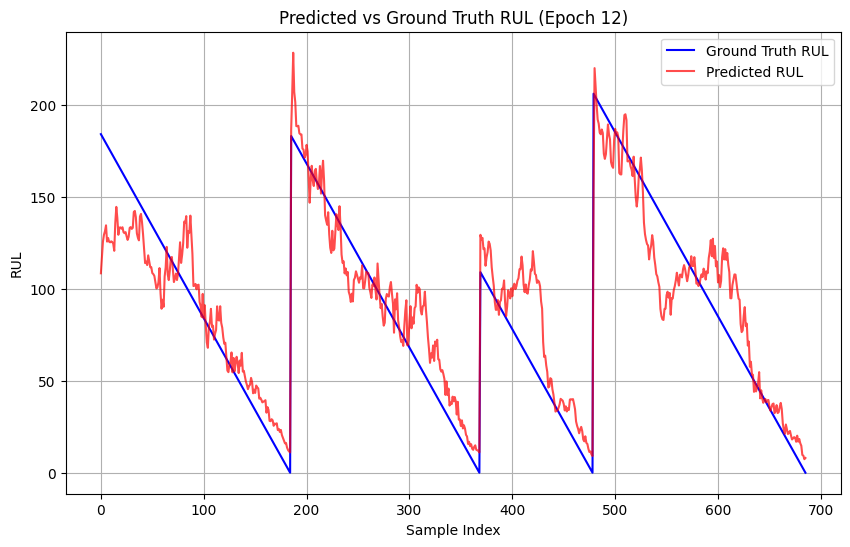

Epoch 13 | Batch 50/2296 | Batch Loss: 33.3405
Epoch 13 | Batch 100/2296 | Batch Loss: 28.2070
Epoch 13 | Batch 150/2296 | Batch Loss: 27.3274
Epoch 13 | Batch 200/2296 | Batch Loss: 34.2502
Epoch 13 | Batch 250/2296 | Batch Loss: 26.1738
Epoch 13 | Batch 300/2296 | Batch Loss: 33.2247
Epoch 13 | Batch 350/2296 | Batch Loss: 43.8793
Epoch 13 | Batch 400/2296 | Batch Loss: 28.9132
Epoch 13 | Batch 450/2296 | Batch Loss: 40.7417
Epoch 13 | Batch 500/2296 | Batch Loss: 29.1689
Epoch 13 | Batch 550/2296 | Batch Loss: 34.0128
Epoch 13 | Batch 600/2296 | Batch Loss: 30.1232
Epoch 13 | Batch 650/2296 | Batch Loss: 39.8394
Epoch 13 | Batch 700/2296 | Batch Loss: 31.9388
Epoch 13 | Batch 750/2296 | Batch Loss: 32.5060
Epoch 13 | Batch 800/2296 | Batch Loss: 31.1634
Epoch 13 | Batch 850/2296 | Batch Loss: 31.3035
Epoch 13 | Batch 900/2296 | Batch Loss: 28.5931
Epoch 13 | Batch 950/2296 | Batch Loss: 30.4559
Epoch 13 | Batch 1000/2296 | Batch Loss: 20.3696
Epoch 13 | Batch 1050/2296 | Batch Loss:

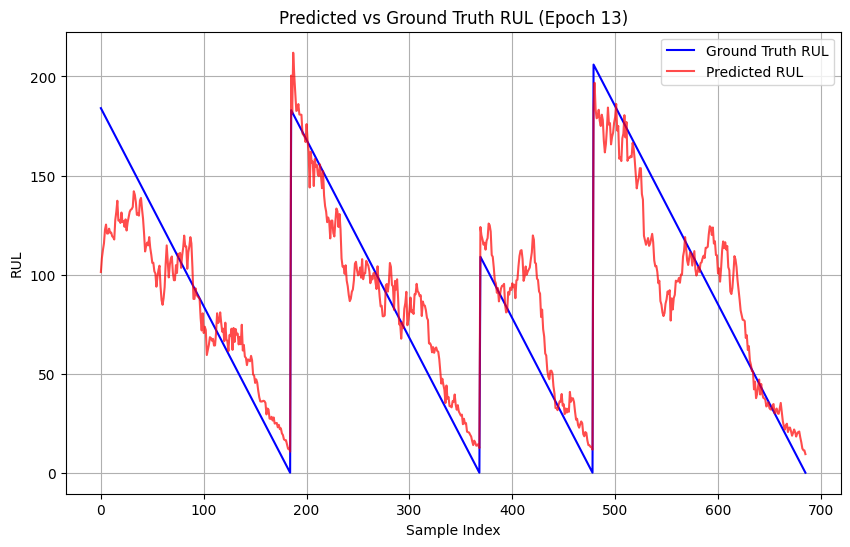

Epoch 14 | Batch 50/2296 | Batch Loss: 21.5398
Epoch 14 | Batch 100/2296 | Batch Loss: 26.8197
Epoch 14 | Batch 150/2296 | Batch Loss: 31.1783
Epoch 14 | Batch 200/2296 | Batch Loss: 35.0487
Epoch 14 | Batch 250/2296 | Batch Loss: 27.9019
Epoch 14 | Batch 300/2296 | Batch Loss: 27.2913
Epoch 14 | Batch 350/2296 | Batch Loss: 26.1768
Epoch 14 | Batch 400/2296 | Batch Loss: 31.6739
Epoch 14 | Batch 450/2296 | Batch Loss: 30.3477
Epoch 14 | Batch 500/2296 | Batch Loss: 25.7711
Epoch 14 | Batch 550/2296 | Batch Loss: 26.9966
Epoch 14 | Batch 600/2296 | Batch Loss: 26.0267
Epoch 14 | Batch 650/2296 | Batch Loss: 33.4331
Epoch 14 | Batch 700/2296 | Batch Loss: 27.0251
Epoch 14 | Batch 750/2296 | Batch Loss: 32.5643
Epoch 14 | Batch 800/2296 | Batch Loss: 26.6732
Epoch 14 | Batch 850/2296 | Batch Loss: 24.8069
Epoch 14 | Batch 900/2296 | Batch Loss: 25.9818
Epoch 14 | Batch 950/2296 | Batch Loss: 46.3536
Epoch 14 | Batch 1000/2296 | Batch Loss: 25.8768
Epoch 14 | Batch 1050/2296 | Batch Loss:

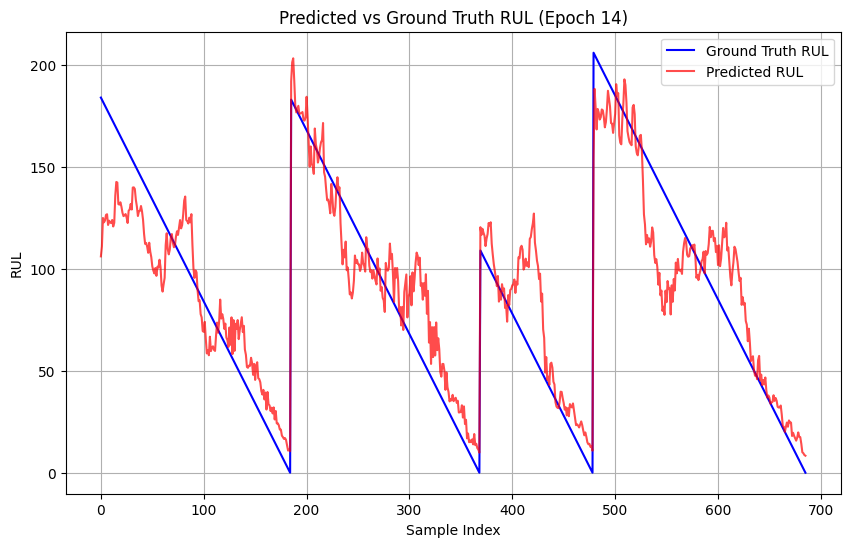

Epoch 15 | Batch 50/2296 | Batch Loss: 31.7681
Epoch 15 | Batch 100/2296 | Batch Loss: 28.8111
Epoch 15 | Batch 150/2296 | Batch Loss: 18.2360
Epoch 15 | Batch 200/2296 | Batch Loss: 27.7900
Epoch 15 | Batch 250/2296 | Batch Loss: 26.4368
Epoch 15 | Batch 300/2296 | Batch Loss: 29.8411
Epoch 15 | Batch 350/2296 | Batch Loss: 31.0653
Epoch 15 | Batch 400/2296 | Batch Loss: 27.0309
Epoch 15 | Batch 450/2296 | Batch Loss: 26.4742
Epoch 15 | Batch 500/2296 | Batch Loss: 41.2536
Epoch 15 | Batch 550/2296 | Batch Loss: 30.7362
Epoch 15 | Batch 600/2296 | Batch Loss: 36.6397
Epoch 15 | Batch 650/2296 | Batch Loss: 28.0686
Epoch 15 | Batch 700/2296 | Batch Loss: 24.2427
Epoch 15 | Batch 750/2296 | Batch Loss: 26.2198
Epoch 15 | Batch 800/2296 | Batch Loss: 31.2929
Epoch 15 | Batch 850/2296 | Batch Loss: 30.9376
Epoch 15 | Batch 900/2296 | Batch Loss: 37.6862
Epoch 15 | Batch 950/2296 | Batch Loss: 28.9451
Epoch 15 | Batch 1000/2296 | Batch Loss: 21.8226
Epoch 15 | Batch 1050/2296 | Batch Loss:

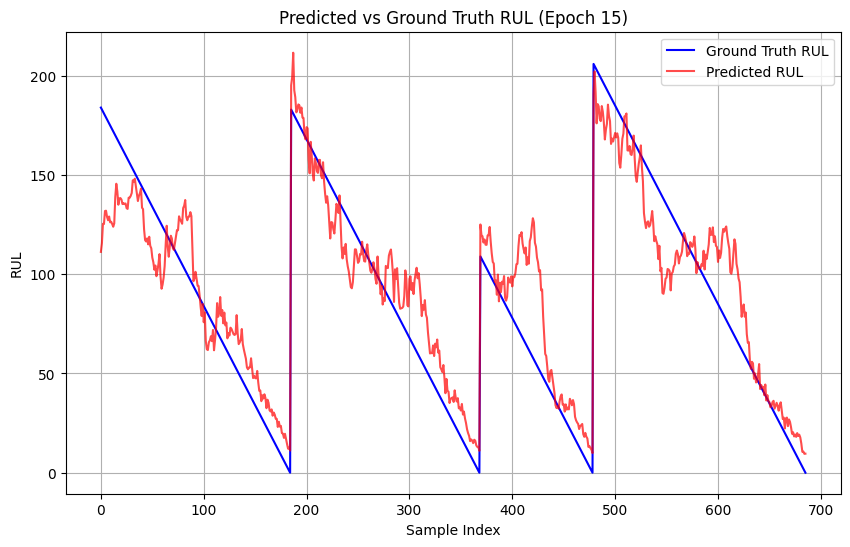

In [ ]:
def train_model(model, train_loader, val_loader, optimizer, scheduler,
                num_epochs=20, alpha=0.1, interval=20, clip_value=1.0):

    for epoch in range(num_epochs):
        model.train()
        tot_loss = 0.0

        for batch_idx, (Xs, Xo, y) in enumerate(train_loader):
            Xs, Xo, y = Xs.to(device), Xo.to(device), y.to(device)

            optimizer.zero_grad()
            pred = model(Xs, Xo)
            loss = fused_loss(pred, y, alpha=alpha)
            loss.backward()

            torch.nn.utils.clip_grad_norm_(model.parameters(), clip_value)
            optimizer.step()
            tot_loss += loss.item()

            if (batch_idx + 1) % interval == 0:
                print(f"Epoch {epoch+1} | Batch {batch_idx+1}/{len(train_loader)} "
                      f"| Batch Loss: {loss.item():.4f}")

        avg_loss = tot_loss / len(train_loader)
        print(f"Epoch {epoch+1}/{num_epochs} - Training Loss: {avg_loss:.4f}")

        # Validation
        model.eval()
        val_loss = 0.0
        all_preds, all_targets = [], []

        with torch.no_grad():
            for Xs, Xo, y in val_loader:
                Xs, Xo, y = Xs.to(device), Xo.to(device), y.to(device)
                pred = model(Xs, Xo)
                loss = fused_loss(pred, y, alpha=alpha)
                val_loss += loss.item()
                all_preds.append(pred.cpu())
                all_targets.append(y.cpu())

        avg_val_loss = val_loss / len(val_loader)
        all_preds = torch.cat(all_preds).squeeze()
        all_targets = torch.cat(all_targets).squeeze()

        nasa = nasa_score(all_preds, all_targets)

        preds = all_preds.detach().numpy().ravel()
        targs = all_targets.detach().numpy().ravel()
        diff  = preds - targs
        print(f"Over %: {(diff>=0).mean()*100:.1f} | "
              f"Mean err: {diff.mean():.2f} | Median err: {np.median(diff):.2f}")
        print(f"Epoch {epoch+1} - Validation Loss: {avg_val_loss:.4f} | NASA Score: {nasa:.2f}")

        scheduler.step(avg_val_loss)

        plt.figure(figsize=(10, 6))
        plt.plot(targs, label='Ground Truth RUL', color='blue')
        plt.plot(preds, label='Predicted RUL', color='red', alpha=0.7)
        plt.title(f'Predicted vs Ground Truth RUL (Epoch {epoch+1})')
        plt.xlabel('Sample Index')
        plt.ylabel('RUL')
        plt.legend()
        plt.grid(True)
        plt.show()


model = RULFusionModel().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)
num_epochs = 15
train_model(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    num_epochs=num_epochs,
    alpha=0.1,       # weight for NASA penalty in fused loss
    interval=50,     # print batch loss every 50 batches
    clip_value=1.0   # gradient clipping threshold
)


In [ ]:
torch.save(model.state_dict(), "model_weights.pth")